# Learn Latent Input — Analysis

Analyse the 3-phase training run: CMA-ES → gradient scaling factors → full gradient (weights + scaling).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import toml
import torch
import zarr
from scipy.stats import mannwhitneyu, pearsonr
from tqdm.auto import tqdm

from connectome_snns.utils.reproducibility import load_experiment_config
from connectome_snns.visualization import (
    use_project_style,
    EXCITATORY_COLOR,
    INHIBITORY_COLOR,
    TEACHER_COLOR,
    STUDENT_COLOR,
    plot_firing_rate_scatter,
    plot_r2_comparison_bar,
    plot_spike_trains,
    plot_sf_bar_chart,
)
from connectome_snns.visualization.scaling_factors import SF_PATHWAYS, plot_sf_trajectories
from connectome_snns.analysis import (
    r_squared,
    fluctuation_r_squared,
    firing_rates_from_spikes,
    interleave_spike_trains,
)
from connectome_snns.analysis.inference import run_feedforward_inference
from connectome_snns.analysis.firing_statistics import compute_spike_train_cv
from connectome_snns.analysis.voltage_statistics import compute_membrane_potential_by_cell_type
from connectome_snns.configs import StudentSimulationConfig, StudentHyperparameters
from connectome_snns.configs.conductance_based import RecurrentLayerConfig, FeedforwardLayerConfig
from connectome_snns.network_simulators.feedforward_conductance_based.simulator import (
    FeedforwardConductanceLIFNetwork,
)
from connectome_snns.network_simulators.projections import make_frozen_chunked_ff_projections

use_project_style()

In [2]:
config = load_experiment_config("experiment.toml")
RESULTS_DIR = config["output_dir"]
PARAMS_FILE = config["parameters_file"]

MAX_RATE = 40
TICKS = np.arange(0, MAX_RATE + 10, 10)
TAU_MS = 50.0
N_NEURONS_RASTER = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CELL_TYPE_COLORS = {0: EXCITATORY_COLOR, 1: INHIBITORY_COLOR}

In [3]:
RUN_DIR = RESULTS_DIR

df = pd.read_csv(RUN_DIR / "training_metrics.csv")
print(f"Run: {RUN_DIR}")
print(f"  {len(df)} logged steps")

# Load network structures
ns_init = np.load(RUN_DIR / "initial_state" / "network_structure.npz")
ns_final = np.load(RUN_DIR / "final_state" / "network_structure.npz")
ns_teacher = np.load(RUN_DIR / "inputs" / "network_structure.npz")
cell_type_indices = ns_final["cell_type_indices"]
assembly_ids = ns_teacher["assembly_ids"]
n_neurons = len(cell_type_indices)

# Load zarr metadata
zarr_root = zarr.open_group(RUN_DIR / "inputs" / "spike_data.zarr", mode="r")
dt = float(zarr_root.attrs["dt"])
n_latents = zarr_root["weights"].shape[2]

print(f"  {n_neurons} neurons, {n_latents} latents, dt={dt} ms")
print(f"  {len(np.unique(assembly_ids))} assemblies")

# Load target scaling factors
targets = np.load(RUN_DIR / "targets" / "target_scaling_factors.npz")
target_sf_rec = targets["recurrent_scaling_factors"]  # (2, 2)

# Identify phases in the log
cma_rows = df[df["epoch"] < 0]
gradient_rows = df[df["epoch"] >= 0]
print(f"  CMA-ES: {len(cma_rows)} logged generations")
print(f"  Gradient: {len(gradient_rows)} logged steps")

Run: /tachyon/groups/scratch/gzenke/bedfrory/dp-simulations/inferring-inputs/learn-latent-input
  2521 logged steps
  5000 neurons, 20 latents, dt=1.0 ms
  20 assemblies
  CMA-ES: 21 logged generations
  Gradient: 2500 logged steps


## Training Curves

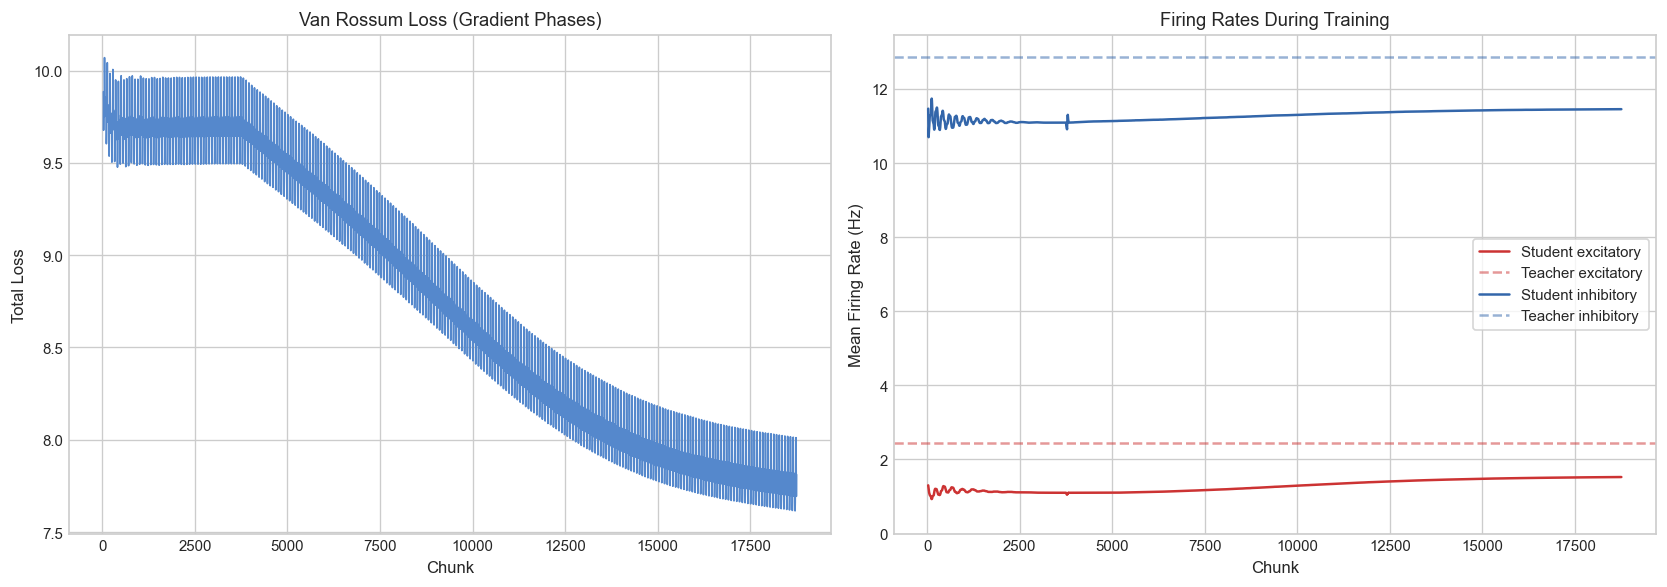

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: loss over gradient phase
ax = axes[0]
grad = gradient_rows
ax.plot(grad["epoch"], grad["total_loss"], color=STUDENT_COLOR, linewidth=1)
ax.set_xlabel("Chunk")
ax.set_ylabel("Total Loss")
ax.set_title("Van Rossum Loss (Gradient Phases)")

# Right: firing rates over gradient phase
ax = axes[1]
for ct_label, color in [
    ("excitatory", EXCITATORY_COLOR),
    ("inhibitory", INHIBITORY_COLOR),
]:
    col = f"firing_rate/student_{ct_label}_mean"
    teacher_col = f"firing_rate/teacher_{ct_label}_mean"
    if col in grad.columns:
        ax.plot(grad["epoch"], grad[col], color=color, label=f"Student {ct_label}")
    if teacher_col in grad.columns:
        ax.axhline(
            grad[teacher_col].dropna().iloc[-1],
            color=color,
            linewidth=1.5,
            linestyle="--",
            alpha=0.5,
            label=f"Teacher {ct_label}",
        )

ax.set_xlabel("Chunk")
ax.set_ylabel("Mean Firing Rate (Hz)")
ax.set_title("Firing Rates During Training")
ax.set_ylim(0, None)
ax.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

## Scaling Factor Recovery

Available SF pathways: ['excitatory_to_excitatory', 'excitatory_to_inhibitory', 'inhibitory_to_excitatory', 'inhibitory_to_inhibitory']


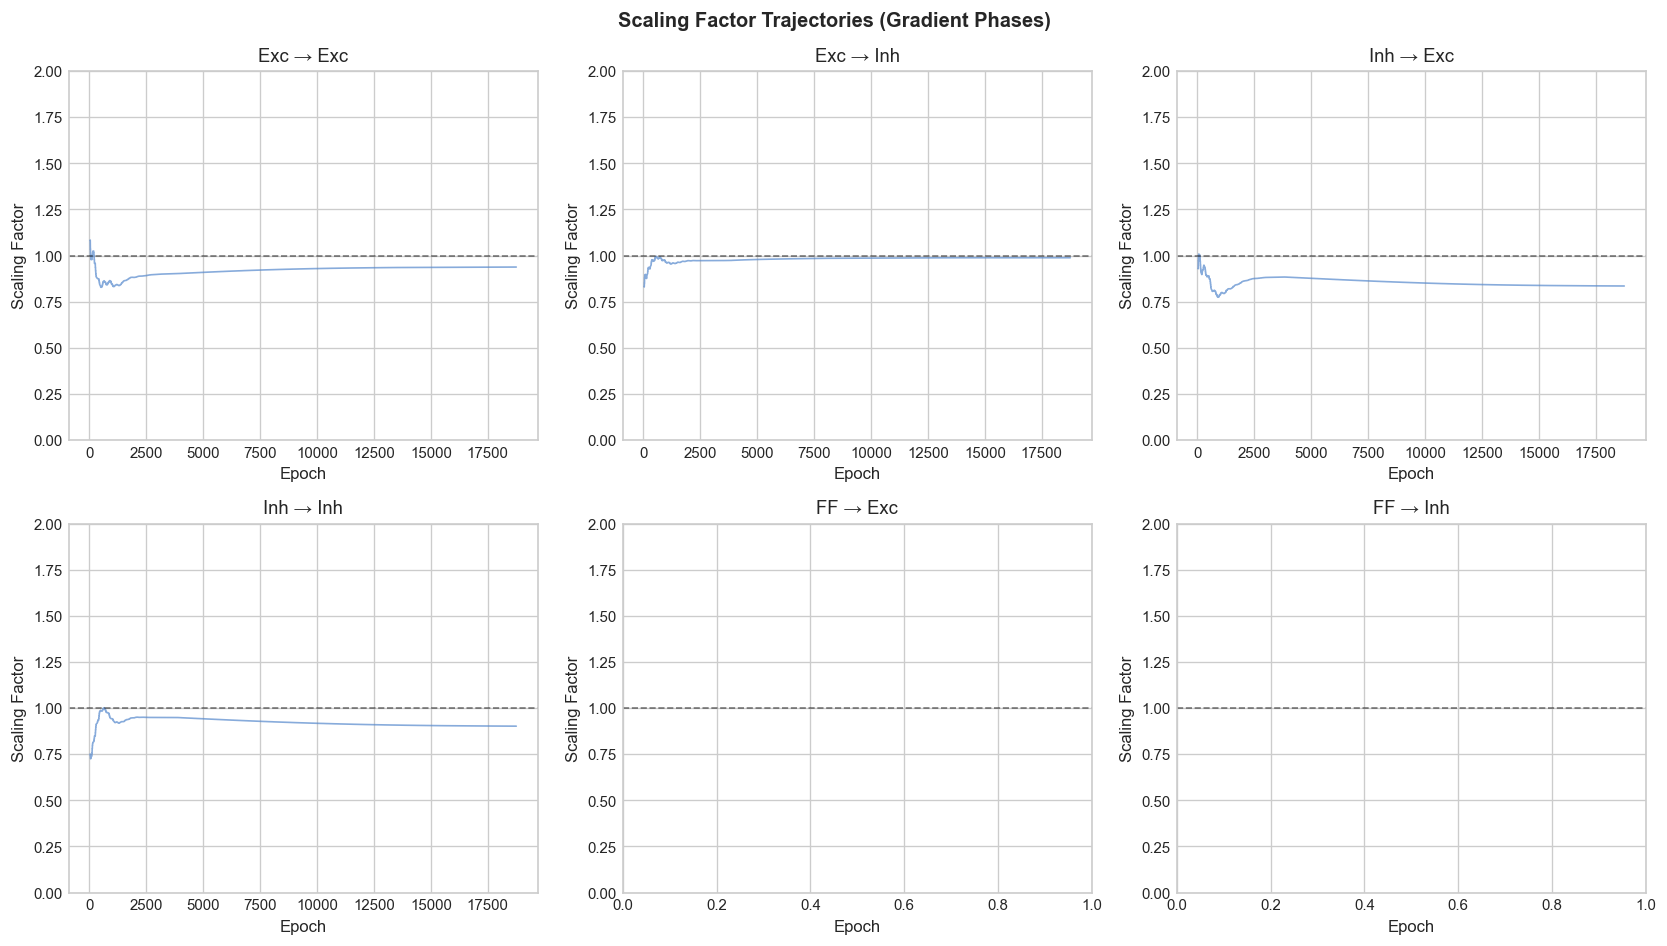

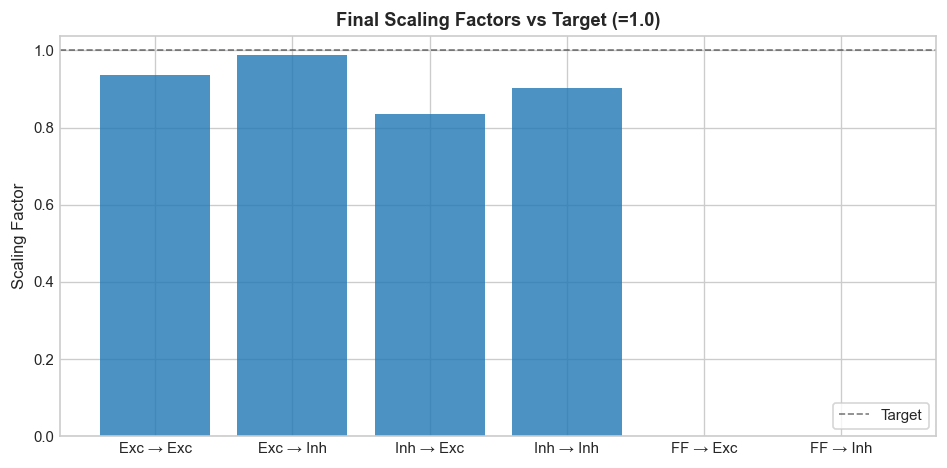


Final recurrent scaling factors (normalised to target):
  Exc → Exc                       0.9374
  Exc → Inh                       0.9878
  Inh → Exc                       0.8347
  Inh → Inh                       0.9016


In [5]:
# Scaling factor trajectories over gradient phase
sf_keys = [key for key, _ in SF_PATHWAYS]

# Filter to the pathways that exist in this experiment
# Our SF matrix is (3, 2): latent→{exc,inh}, exc→{exc,inh}, inh→{exc,inh}
available_sf_keys = [
    k for k in sf_keys if f"scaling_factors/{k}_value" in gradient_rows.columns
]
print(f"Available SF pathways: {available_sf_keys}")

# Trajectories
runs_df_dict = {"run": gradient_rows}
plot_sf_trajectories(
    runs_df_dict,
    colors={"run": STUDENT_COLOR},
    label_fn=lambda k: "Student",
    suptitle="Scaling Factor Trajectories (Gradient Phases)",
)
plt.show()

# Final values as bar chart
final_row = gradient_rows.iloc[-1]
sf_final = {
    key: float(final_row[f"scaling_factors/{key}_value"]) for key in available_sf_keys
}

plot_sf_bar_chart(
    sf_final,
    figsize=(8, 4),
    title="Final Scaling Factors vs Target (=1.0)",
)
plt.show()

# Print final values
print("\nFinal recurrent scaling factors (normalised to target):")
for key in available_sf_keys:
    label = dict(SF_PATHWAYS).get(key, key)
    print(f"  {label:<30s}  {sf_final[key]:.4f}")

## Learned Feedforward Weight Matrix

Learned latent→neuron weight matrix statistics:
  Shape: (20, 5000)
  Mean:  0.012995
  Std:   0.006263
  Min:   0.002582
  Max:   0.034806
  → Excitatory: mean=0.015262, std=0.004771
  → Inhibitory: mean=0.003925, std=0.001499

Saved scaling factors:
[[1. 1.]
 [1. 1.]
 [1. 1.]]


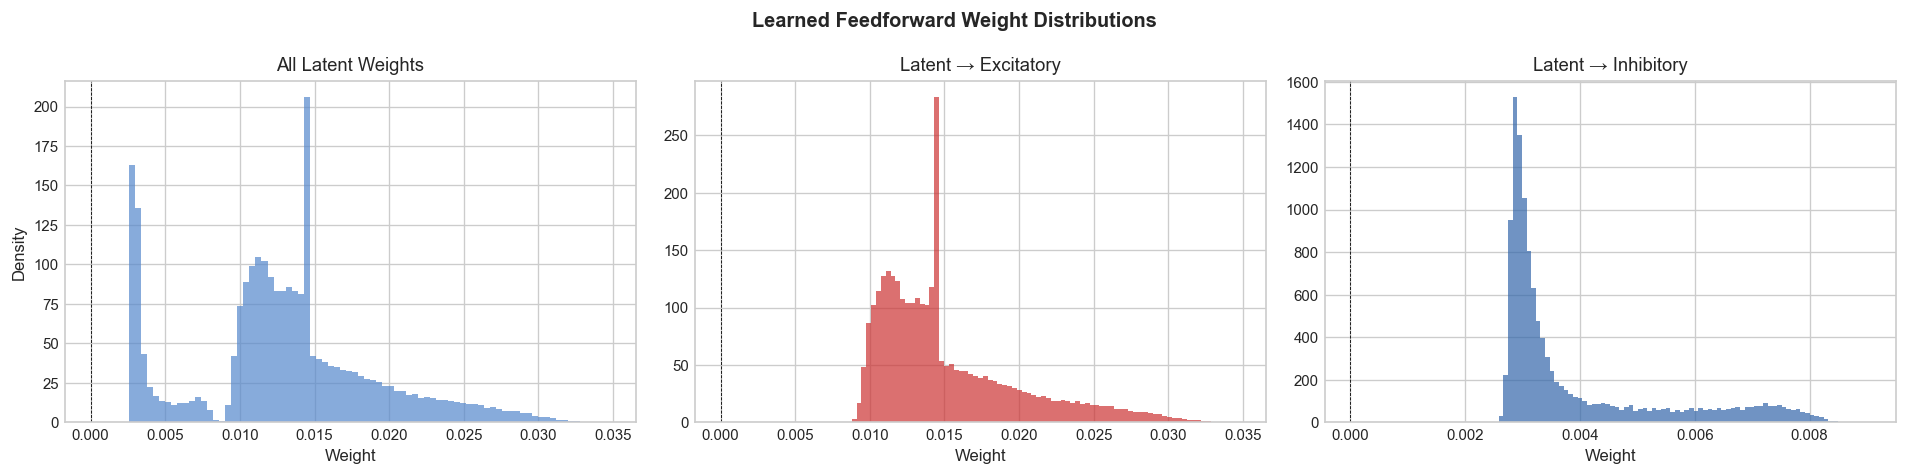


Assembly specificity (within cell type):
  E: same=0.016853, other=0.015179, diff=0.001674, d=0.315, p=1.94e-51
  I: same=0.003860, other=0.003929, diff=-0.000069, d=-0.046, p=2.35e-02


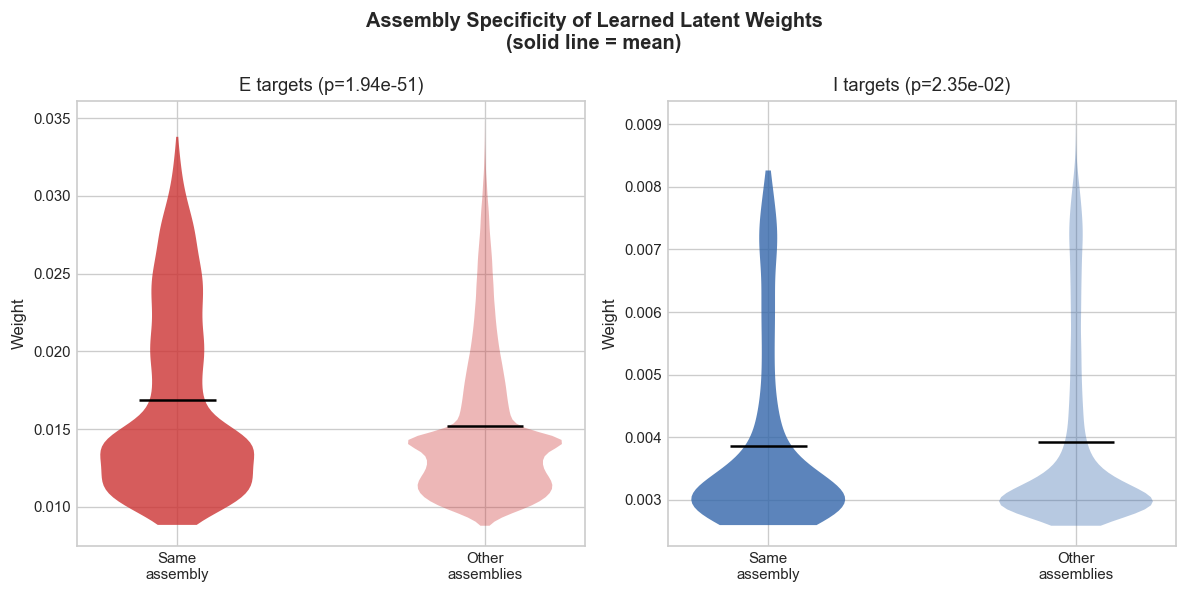

In [6]:
# Final learned weights (note: scaling factors may not be baked in — check ns_final["scaling_factors_FF"])
final_weights = ns_final["feedforward_weights"]
latent_w = final_weights[:n_latents, :]  # (n_latents, n_neurons)
rec_w = final_weights[n_latents:, :]  # (n_neurons, n_neurons)

exc_mask = cell_type_indices == 0
inh_mask = cell_type_indices == 1

print("Learned latent→neuron weight matrix statistics:")
print(f"  Shape: {latent_w.shape}")
print(f"  Mean:  {latent_w.mean():.6f}")
print(f"  Std:   {latent_w.std():.6f}")
print(f"  Min:   {latent_w.min():.6f}")
print(f"  Max:   {latent_w.max():.6f}")
print(
    f"  → Excitatory: mean={latent_w[:, exc_mask].mean():.6f}, std={latent_w[:, exc_mask].std():.6f}"
)
print(
    f"  → Inhibitory: mean={latent_w[:, inh_mask].mean():.6f}, std={latent_w[:, inh_mask].std():.6f}"
)

print(f"\nSaved scaling factors:\n{ns_final['scaling_factors_FF']}")

# Weight distributions: histograms per output cell type
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.hist(latent_w.ravel(), bins=80, color=STUDENT_COLOR, alpha=0.7, density=True)
ax.set_xlabel("Weight")
ax.set_ylabel("Density")
ax.set_title("All Latent Weights")
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")

ax = axes[1]
ax.hist(
    latent_w[:, exc_mask].ravel(),
    bins=80,
    color=EXCITATORY_COLOR,
    alpha=0.7,
    density=True,
)
ax.set_xlabel("Weight")
ax.set_title("Latent → Excitatory")
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")

ax = axes[2]
ax.hist(
    latent_w[:, inh_mask].ravel(),
    bins=80,
    color=INHIBITORY_COLOR,
    alpha=0.7,
    density=True,
)
ax.set_xlabel("Weight")
ax.set_title("Latent → Inhibitory")
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")

plt.suptitle("Learned Feedforward Weight Distributions", fontweight="bold")
plt.tight_layout()
plt.show()

# Assembly specificity: within each cell type, compare same-assembly vs other weights
groups = {}
for ct_label, ct_mask in [("E", exc_mask), ("I", inh_mask)]:
    same, diff = [], []
    for i in range(n_latents):
        same.append(latent_w[i, (assembly_ids == i) & ct_mask])
        diff.append(latent_w[i, (assembly_ids != i) & ct_mask])
    groups[f"{ct_label} same"] = np.concatenate(same)
    groups[f"{ct_label} other"] = np.concatenate(diff)

print("\nAssembly specificity (within cell type):")
for ct_label in ["E", "I"]:
    same = groups[f"{ct_label} same"]
    other = groups[f"{ct_label} other"]
    stat, pval = mannwhitneyu(same, other, alternative="two-sided")
    d = (same.mean() - other.mean()) / np.sqrt((same.std() ** 2 + other.std() ** 2) / 2)
    print(
        f"  {ct_label}: same={same.mean():.6f}, other={other.mean():.6f}, "
        f"diff={same.mean() - other.mean():.6f}, d={d:.3f}, p={pval:.2e}"
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, ct_label, color in zip(axes, ["E", "I"], [EXCITATORY_COLOR, INHIBITORY_COLOR]):
    same = groups[f"{ct_label} same"]
    other = groups[f"{ct_label} other"]
    stat, pval = mannwhitneyu(same, other, alternative="two-sided")

    parts = ax.violinplot(
        [same, other],
        positions=[0, 1],
        showmeans=True,
        showmedians=False,
        showextrema=False,
    )
    for pc, alpha in zip(parts["bodies"], [0.8, 0.35]):
        pc.set_facecolor(color)
        pc.set_alpha(alpha)
    parts["cmeans"].set_color("k")
    parts["cmeans"].set_linewidth(1.5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Same\nassembly", "Other\nassemblies"])
    ax.set_ylabel("Weight")
    ax.set_title(f"{ct_label} targets (p={pval:.2e})")

plt.suptitle(
    "Assembly Specificity of Learned Latent Weights\n(solid line = mean)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## What Drives Weight Structure?

The within-cell-type weight distributions are bimodal. Is this assembly specificity
(latent $i$ learning stronger weights to assembly $i$)? Or something else?

**Per-neuron correlations.** The learned weights track each neuron's total teacher FF
input (r~0.77), not assembly membership. The teacher's total FF input per neuron is
log-normal (as expected from the network generation), so the bimodality is NOT inherited
from the teacher. Instead, it likely arises from an interaction between limited training
(~100 epochs) and gradient clipping: neurons with high teacher FF input require the
largest weight increases from the uniform initialisation, so their weights have been
pushed at the maximum clipped gradient for the entire trajectory — bunching them against
an effective ceiling. Neurons with lower teacher FF input have had time to spread out
towards their targets, forming the lower mode.

**Assembly-level specificity.** When we aggregate weights at the assembly level (summing
all weights from latent $i$ to each assembly $a$), a strong effect emerges for
**excitatory** targets: each latent projects substantially more total weight to its
corresponding assembly than to other assemblies. This is expected — in the teacher
network, mitral cells are assigned to latents based on their summed FF weights to
**excitatory** neurons in each assembly (`target_cell_type_idx=0` in
`generate_odour_firing_rates`). Each assembly's excitatory neurons receive structured,
latent-specific FF drive, so the student must learn assembly-specific weights to
reproduce this.

**No effect for inhibitory targets.** The latent→assembly mapping in the teacher is
defined entirely through excitatory connectivity. Inhibitory neurons receive FF input
but their weights don't define the latent-assembly structure — they just need to match
the total FF drive per neuron, not its assembly membership. Accordingly, the learned
latent→I weights show no assembly specificity.

Correlation: mean learned latent weight vs teacher total FF input
  Excitatory: r=0.8002, p=0.00e+00
  Inhibitory: r=0.5507, p=2.18e-80

Assembly-level specificity (sum of weights per latent→assembly pair):
  E: same=3.37, other=3.04, d=2.880, p=3.30e-13
  I: same=0.19, other=0.20, d=-0.149, p=4.89e-01


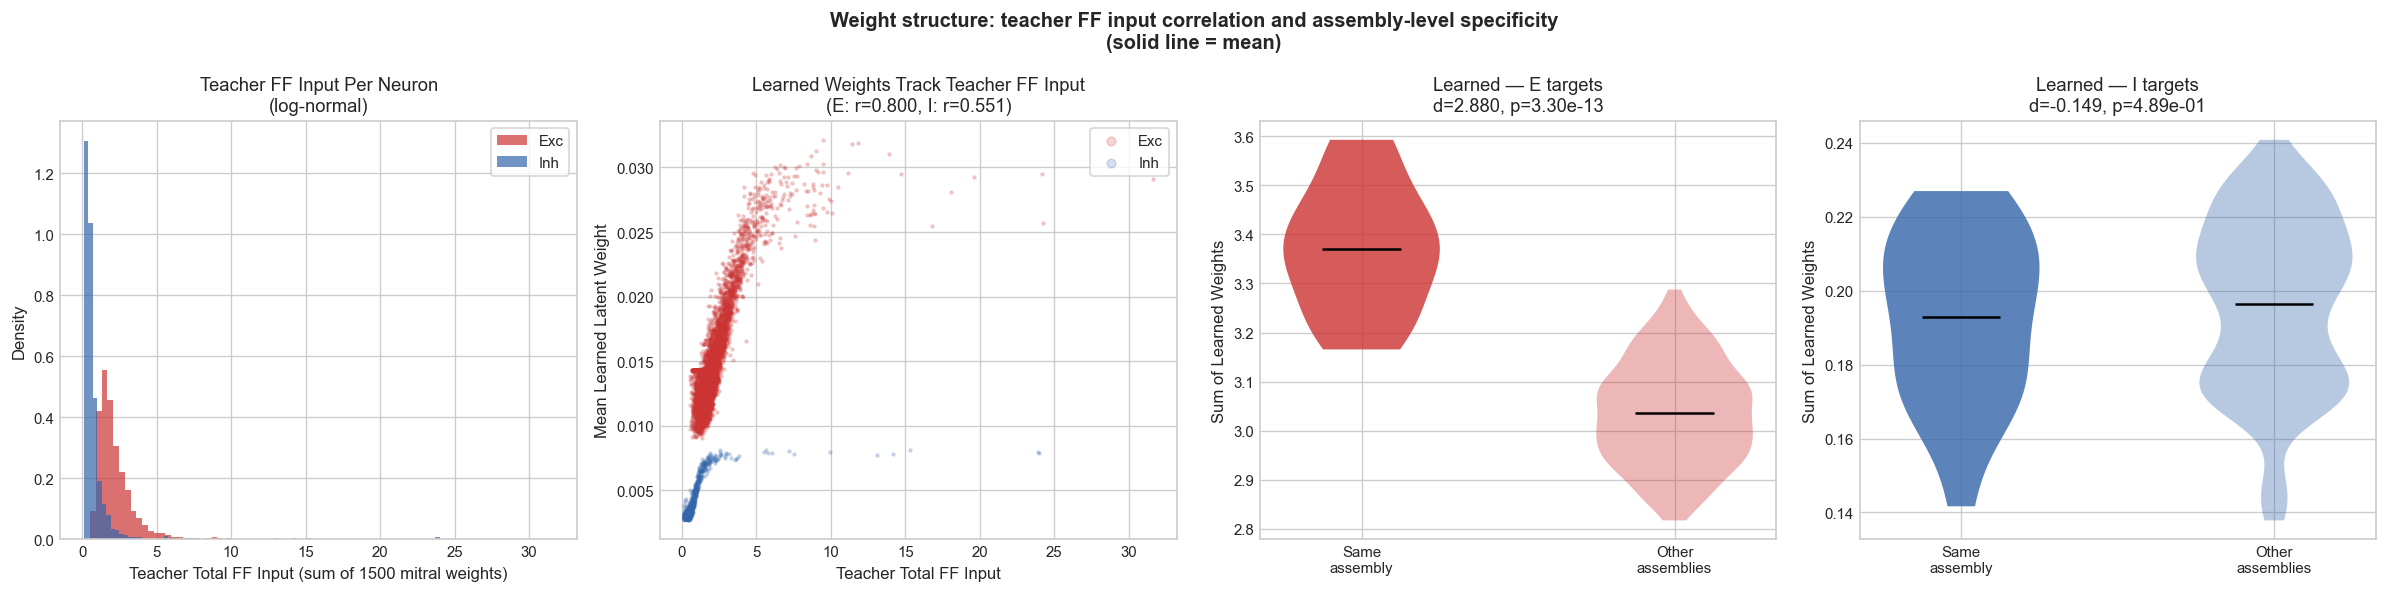

In [7]:
# Load teacher FF weights to compute total FF input per neuron
teacher_ff_w = ns_teacher["feedforward_weights"]  # (1500, 5000)
teacher_total_ff = teacher_ff_w.sum(axis=0)  # total FF weight per neuron

# Mean learned latent weight per neuron (averaged across all 20 latents)
mean_latent_w = latent_w.mean(axis=0)  # (n_neurons,)

r_exc, p_exc = pearsonr(mean_latent_w[exc_mask], teacher_total_ff[exc_mask])
r_inh, p_inh = pearsonr(mean_latent_w[inh_mask], teacher_total_ff[inh_mask])

print("Correlation: mean learned latent weight vs teacher total FF input")
print(f"  Excitatory: r={r_exc:.4f}, p={p_exc:.2e}")
print(f"  Inhibitory: r={r_inh:.4f}, p={p_inh:.2e}")

# Assembly-level specificity: sum weights from each latent to each assembly
n_assemblies = len(np.unique(assembly_ids))
assembly_sums = {}

for ct_label, ct_m in [("E", exc_mask), ("I", inh_mask)]:
    same, other = [], []
    for latent_idx in range(n_latents):
        for a in range(n_assemblies):
            mask = (assembly_ids == a) & ct_m
            w_sum = latent_w[latent_idx, mask].sum()
            if a == latent_idx:
                same.append(w_sum)
            else:
                other.append(w_sum)
    assembly_sums[ct_label] = {"same": np.array(same), "other": np.array(other)}

print("\nAssembly-level specificity (sum of weights per latent→assembly pair):")
for ct_label in ["E", "I"]:
    s = assembly_sums[ct_label]["same"]
    o = assembly_sums[ct_label]["other"]
    stat, pval = mannwhitneyu(s, o, alternative="two-sided")
    d = (s.mean() - o.mean()) / np.sqrt((s.std() ** 2 + o.std() ** 2) / 2)
    print(
        f"  {ct_label}: same={s.mean():.2f}, other={o.mean():.2f}, d={d:.3f}, p={pval:.2e}"
    )

# --- Plots ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Teacher total FF input distribution
ax = axes[0]
ax.hist(
    teacher_total_ff[exc_mask],
    bins=80,
    color=EXCITATORY_COLOR,
    alpha=0.7,
    density=True,
    label="Exc",
)
ax.hist(
    teacher_total_ff[inh_mask],
    bins=80,
    color=INHIBITORY_COLOR,
    alpha=0.7,
    density=True,
    label="Inh",
)
ax.set_xlabel("Teacher Total FF Input (sum of 1500 mitral weights)")
ax.set_ylabel("Density")
ax.set_title("Teacher FF Input Per Neuron\n(log-normal)")
ax.legend(frameon=True)

# Scatter of learned weight vs teacher FF input
ax = axes[1]
ax.scatter(
    teacher_total_ff[exc_mask],
    mean_latent_w[exc_mask],
    s=3,
    alpha=0.2,
    color=EXCITATORY_COLOR,
    rasterized=True,
    label="Exc",
)
ax.scatter(
    teacher_total_ff[inh_mask],
    mean_latent_w[inh_mask],
    s=3,
    alpha=0.2,
    color=INHIBITORY_COLOR,
    rasterized=True,
    label="Inh",
)
ax.set_xlabel("Teacher Total FF Input")
ax.set_ylabel("Mean Learned Latent Weight")
ax.set_title(
    f"Learned Weights Track Teacher FF Input\n(E: r={r_exc:.3f}, I: r={r_inh:.3f})"
)
ax.legend(frameon=True, markerscale=3)

# Assembly-level violins: learned E
ax = axes[2]
s = assembly_sums["E"]["same"]
o = assembly_sums["E"]["other"]
_, pval = mannwhitneyu(s, o, alternative="two-sided")
d = (s.mean() - o.mean()) / np.sqrt((s.std() ** 2 + o.std() ** 2) / 2)

parts = ax.violinplot(
    [s, o], positions=[0, 1], showmeans=True, showmedians=False, showextrema=False
)
for pc, alpha in zip(parts["bodies"], [0.8, 0.35]):
    pc.set_facecolor(EXCITATORY_COLOR)
    pc.set_alpha(alpha)
parts["cmeans"].set_color("k")
parts["cmeans"].set_linewidth(1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Same\nassembly", "Other\nassemblies"])
ax.set_ylabel("Sum of Learned Weights")
ax.set_title(f"Learned — E targets\nd={d:.3f}, p={pval:.2e}")

# Assembly-level violins: learned I
ax = axes[3]
s = assembly_sums["I"]["same"]
o = assembly_sums["I"]["other"]
_, pval = mannwhitneyu(s, o, alternative="two-sided")
d = (s.mean() - o.mean()) / np.sqrt((s.std() ** 2 + o.std() ** 2) / 2)

parts = ax.violinplot(
    [s, o], positions=[0, 1], showmeans=True, showmedians=False, showextrema=False
)
for pc, alpha in zip(parts["bodies"], [0.8, 0.35]):
    pc.set_facecolor(INHIBITORY_COLOR)
    pc.set_alpha(alpha)
parts["cmeans"].set_color("k")
parts["cmeans"].set_linewidth(1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Same\nassembly", "Other\nassemblies"])
ax.set_ylabel("Sum of Learned Weights")
ax.set_title(f"Learned — I targets\nd={d:.3f}, p={pval:.2e}")

plt.suptitle(
    "Weight structure: teacher FF input correlation and assembly-level specificity\n(solid line = mean)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Inference: Firing Rates and Fluctuation R²

In [8]:
# Run inference with the trained model using final-state weights + scaling factors
cache_path = RUN_DIR / "final_state" / "inference_cache.npz"

# OU latent activations as FF input
ou_weights = np.array(zarr_root["weights"][0], dtype=np.float32)  # (time, n_latents)

# Use actual saved scaling factors (they may or may not be baked into weights)
scaling_factors_FF = ns_final["scaling_factors_FF"]

data = run_feedforward_inference(
    params_file=PARAMS_FILE,
    run_dir=RUN_DIR,
    scaling_factors_FF=scaling_factors_FF,
    ff_input=ou_weights,
    network_structure_path=RUN_DIR / "final_state" / "network_structure.npz",
    cache_path=cache_path,
    device=DEVICE,
    desc="latent-input inference",
)

teacher_spikes = data["teacher_spikes"]
student_spikes = data["student_spikes"]
ct = data["cell_type_indices"]
inf_dt = float(data["dt"])

duration_s = teacher_spikes.shape[0] * inf_dt / 1000.0
print(f"Inference: {duration_s:.1f}s of data, {teacher_spikes.shape[1]} neurons")

Inference: 5.0s of data, 5000 neurons


Activity R²:     0.8153
Fluctuation R²:  0.7885


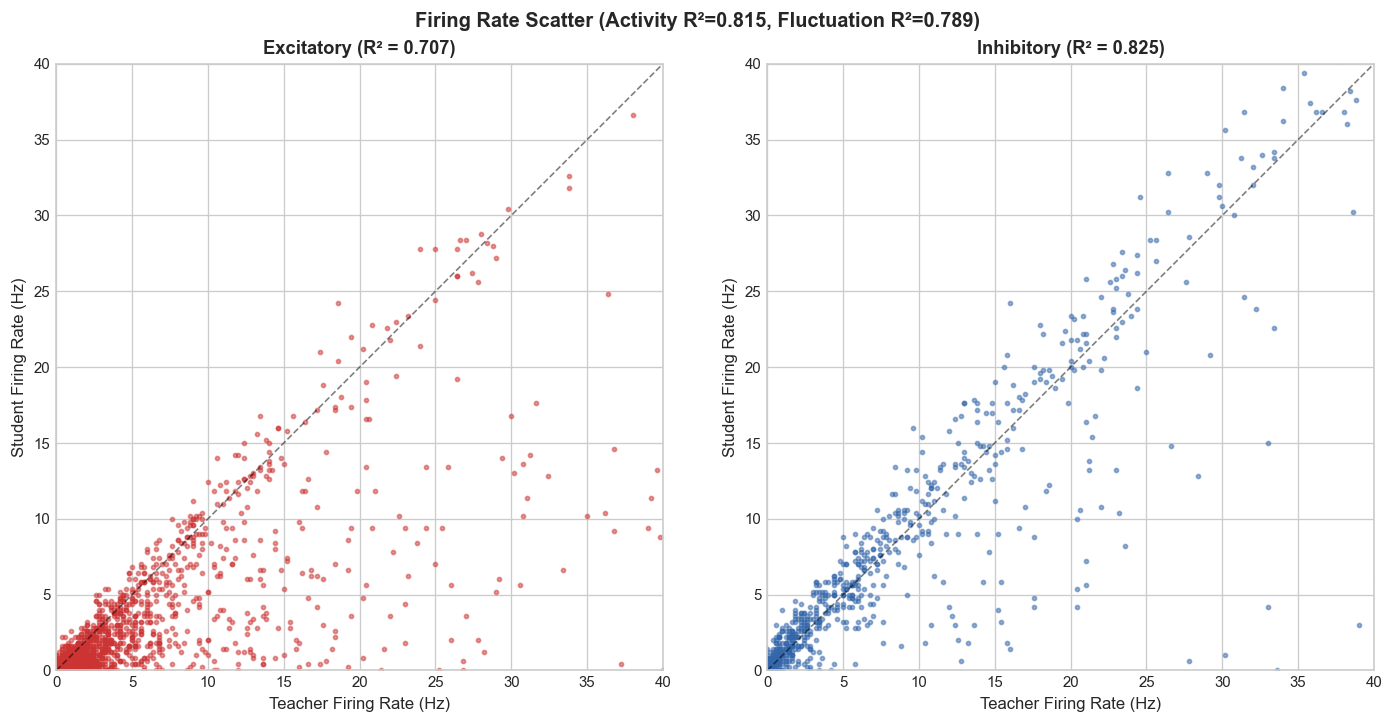

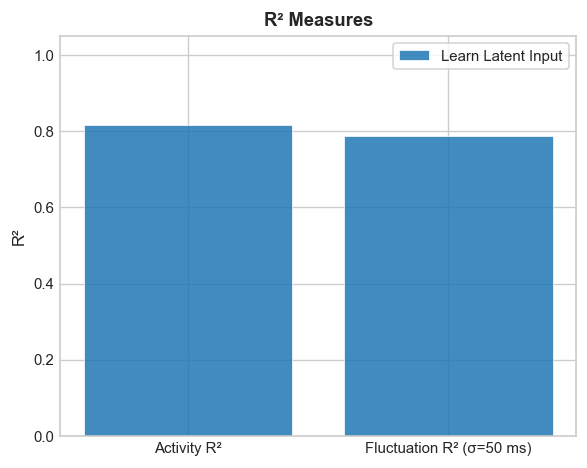

In [9]:
teacher_fr = firing_rates_from_spikes(teacher_spikes, inf_dt)
student_fr = firing_rates_from_spikes(student_spikes, inf_dt)

r2_act = r_squared(teacher_fr, student_fr)
r2_flu = fluctuation_r_squared(
    teacher_spikes.astype(np.float32),
    student_spikes.astype(np.float32),
    TAU_MS,
    inf_dt,
)

print(f"Activity R²:     {r2_act:.4f}")
print(f"Fluctuation R²:  {r2_flu:.4f}")

# Firing rate scatter
plot_firing_rate_scatter(
    teacher_fr,
    student_fr,
    ct,
    split_panels=True,
    max_rate=MAX_RATE,
    marker_size=6,
    rasterized=True,
    figsize=(12, 6),
)
plt.suptitle(
    f"Firing Rate Scatter (Activity R²={r2_act:.3f}, Fluctuation R²={r2_flu:.3f})",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# R² bar chart
plot_r2_comparison_bar(
    ["Learn Latent Input"],
    {
        "Activity R²": [r2_act],
        f"Fluctuation R² (σ={TAU_MS:.0f} ms)": [r2_flu],
    },
    title="R² Measures",
    figsize=(5, 4),
)
plt.show()

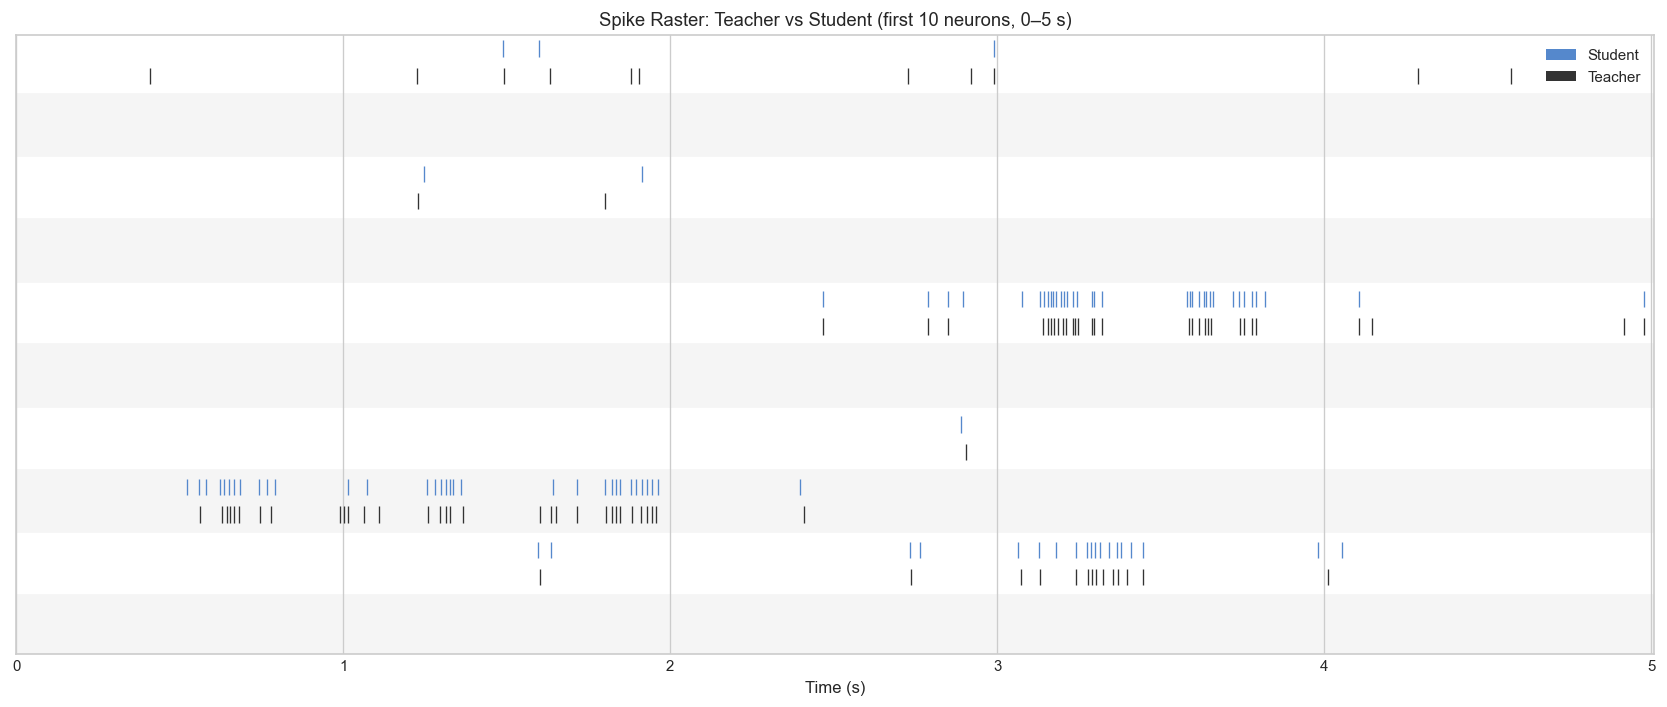

In [10]:
# Spike raster comparison (first 5 seconds)
n_5s = int(5000.0 / inf_dt)
teacher_clip = teacher_spikes[:n_5s, :]
student_clip = student_spikes[:n_5s, :]

interleaved, ct_idx = interleave_spike_trains(
    teacher_clip, student_clip, n_neurons=N_NEURONS_RASTER
)

fig, ax = plt.subplots(figsize=(14, 6))
plot_spike_trains(
    spikes=interleaved,
    dt=inf_dt,
    cell_type_indices=ct_idx,
    cell_type_names=["Teacher", "Student"],
    cell_type_colors={0: TEACHER_COLOR, 1: STUDENT_COLOR},
    n_neurons_plot=2 * N_NEURONS_RASTER,
    n_compared=2,
    fraction=1.0,
    random_seed=None,
    title=f"Spike Raster: Teacher vs Student (first {N_NEURONS_RASTER} neurons, 0–5 s)",
    ax=ax,
)
plt.tight_layout()
plt.show()

## Feedforward vs Recurrent Drive

                                    Student       Teacher
FF drive                         48728415.4    44714873.0
Rec exc drive                    23725372.2    24851468.2
FF fraction                          0.6725        0.6428
Rec exc fraction                     0.3275        0.3572
Ratio (rec exc / FF)                  0.487         0.556


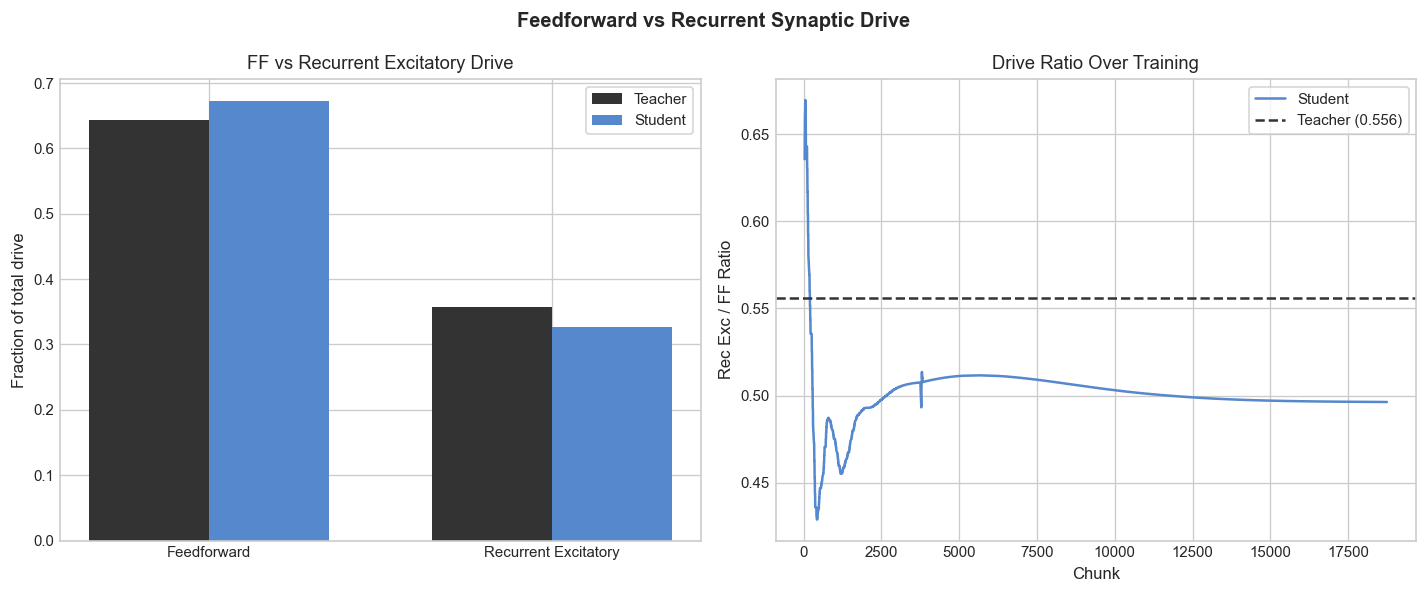

In [11]:
# Feedforward vs Recurrent Excitatory Drive
# Method: activity × total-outgoing-weight, summed over sources
# (matches teacher activity notebook)

teacher_rec_w = ns_teacher["recurrent_weights"]  # (source, target)

# --- Outgoing weights per source neuron ---
# Teacher FF: feedforward_weights is (source, target)
teacher_ff_outgoing = teacher_ff_w.sum(axis=1)  # (n_ff,)
# Teacher rec exc: recurrent_weights is (source, target)
teacher_exc_outgoing = teacher_rec_w[exc_mask, :].sum(axis=1)  # (n_exc,)

# Student FF (latent): latent_w_eff is (source, target)
latent_w_eff = latent_w.copy()
latent_w_eff[:, exc_mask] *= scaling_factors_FF[0, 0]
latent_w_eff[:, inh_mask] *= scaling_factors_FF[0, 1]
student_ff_outgoing = latent_w_eff.sum(axis=1)  # (n_latents,)

# Student rec exc: rec_w_eff is (source, target)
rec_w_eff = rec_w.copy()
for source_type in range(2):
    s_mask = cell_type_indices == source_type
    for target_type in range(2):
        t_mask = cell_type_indices == target_type
        rec_w_eff[np.ix_(s_mask, t_mask)] *= scaling_factors_FF[
            source_type + 1, target_type
        ]
student_exc_outgoing = rec_w_eff[exc_mask, :].sum(axis=1)  # (n_exc,)

# --- Accumulate over all zarr batches ---
n_zarr_batches = zarr_root["input_spikes"].shape[0]
chunk_size_acc = 5000  # timesteps per read chunk

teacher_input_counts = np.zeros(zarr_root["input_spikes"].shape[2], dtype=np.int64)
teacher_output_counts = np.zeros(n_neurons, dtype=np.int64)
student_latent_activity = np.zeros(n_latents, dtype=np.float64)

n_ts = zarr_root["input_spikes"].shape[1]
for b in range(n_zarr_batches):
    for s in range(0, n_ts, chunk_size_acc):
        teacher_input_counts += zarr_root["input_spikes"][
            b, s : s + chunk_size_acc, :
        ].sum(axis=0)
        teacher_output_counts += zarr_root["output_spikes"][
            b, s : s + chunk_size_acc, :
        ].sum(axis=0)
        student_latent_activity += np.array(
            zarr_root["weights"][b, s : s + chunk_size_acc, :], dtype=np.float64
        ).sum(axis=0)

# Teacher drive
teacher_ff_drive = (teacher_input_counts * teacher_ff_outgoing).sum()
teacher_rec_exc_drive = (teacher_output_counts[exc_mask] * teacher_exc_outgoing).sum()
teacher_total = teacher_ff_drive + teacher_rec_exc_drive

# Student drive
student_ff_drive = (student_latent_activity * student_ff_outgoing).sum()
student_rec_exc_drive = (teacher_output_counts[exc_mask] * student_exc_outgoing).sum()
student_total = student_ff_drive + student_rec_exc_drive

print(f"{'':30s} {'Student':>12s}  {'Teacher':>12s}")
print(f"{'FF drive':<30s} {student_ff_drive:12.1f}  {teacher_ff_drive:12.1f}")
print(
    f"{'Rec exc drive':<30s} {student_rec_exc_drive:12.1f}  {teacher_rec_exc_drive:12.1f}"
)
print(
    f"{'FF fraction':<30s} {student_ff_drive / student_total:12.4f}  {teacher_ff_drive / teacher_total:12.4f}"
)
print(
    f"{'Rec exc fraction':<30s} {student_rec_exc_drive / student_total:12.4f}  {teacher_rec_exc_drive / teacher_total:12.4f}"
)
print(
    f"{'Ratio (rec exc / FF)':<30s} {student_rec_exc_drive / student_ff_drive:12.3f}  {teacher_rec_exc_drive / teacher_ff_drive:12.3f}"
)

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: grouped bar chart (normalised fractions)
ax = axes[0]
x = np.arange(2)
width = 0.35
teacher_fracs = [
    teacher_ff_drive / teacher_total,
    teacher_rec_exc_drive / teacher_total,
]
student_fracs = [
    student_ff_drive / student_total,
    student_rec_exc_drive / student_total,
]
ax.bar(x - width / 2, teacher_fracs, width, color=TEACHER_COLOR, label="Teacher")
ax.bar(x + width / 2, student_fracs, width, color=STUDENT_COLOR, label="Student")
ax.set_xticks(x)
ax.set_xticklabels(["Feedforward", "Recurrent Excitatory"])
ax.set_ylabel("Fraction of total drive")
ax.set_title("FF vs Recurrent Excitatory Drive")
ax.legend(frameon=True)

# Right: ratio over training (from logged metrics)
ax = axes[1]
teacher_ratio_rec_ff = teacher_rec_exc_drive / teacher_ff_drive
if "drive/ratio_rec_exc_over_ff" in gradient_rows.columns:
    ax.plot(
        gradient_rows["epoch"],
        gradient_rows["drive/ratio_rec_exc_over_ff"],
        color=STUDENT_COLOR,
        label="Student",
    )
elif "drive/ratio_ff_over_rec_exc" in gradient_rows.columns:
    ax.plot(
        gradient_rows["epoch"],
        1.0 / gradient_rows["drive/ratio_ff_over_rec_exc"],
        color=STUDENT_COLOR,
        label="Student (inverted from old metric)",
    )
ax.axhline(
    teacher_ratio_rec_ff,
    color=TEACHER_COLOR,
    linestyle="--",
    linewidth=1.5,
    label=f"Teacher ({teacher_ratio_rec_ff:.3f})",
)
ax.set_xlabel("Chunk")
ax.set_ylabel("Rec Exc / FF Ratio")
ax.set_title("Drive Ratio Over Training")
ax.legend(frameon=True)

plt.suptitle("Feedforward vs Recurrent Synaptic Drive", fontweight="bold")
plt.tight_layout()
plt.show()

## Membrane Potential Statistics

Run a single trial with voltage tracking for both teacher and student to compare
mean membrane potential and standard deviation by cell type. If the student matches
firing rates but has more feedforward drive, we expect higher mean $V_m$ and lower
fluctuations (i.e. a different operating regime).

In [ ]:
_params = toml.load(PARAMS_FILE)
_sim = StudentSimulationConfig(**_params["simulation"])
_hp = StudentHyperparameters(**_params["hyperparameters"])
_rec_cfg = RecurrentLayerConfig(**_params["recurrent"])
_ff_cfg = FeedforwardLayerConfig(**_params["feedforward"])
chunk_size = _sim.chunk_size

_rec_cell_params = _rec_cfg.get_cell_params()
_ff_cell_params = _ff_cfg.get_cell_params()
_rec_syn_params = _rec_cfg.get_synapse_params()
_ff_syn_params = _ff_cfg.get_synapse_params()
n_ff_cell_types = len(_ff_cell_params)
n_ff_syn_types = len(_ff_syn_params)

_combined_cell_params = _ff_cell_params.copy()
for cp in _rec_cell_params:
    ocp = cp.copy()
    ocp["cell_id"] = cp["cell_id"] + n_ff_cell_types
    _combined_cell_params.append(ocp)

_combined_syn_params = _ff_syn_params.copy()
for sp in _rec_syn_params:
    osp = sp.copy()
    osp["cell_id"] = sp["cell_id"] + n_ff_cell_types
    osp["synapse_id"] = sp["synapse_id"] + n_ff_syn_types
    _combined_syn_params.append(osp)

surrgrad = _hp.surrgrad_scale if _hp.surrgrad_scale is not None else 1.0

_rec_cell_type_names = [c["name"] for c in _rec_cell_params]
_ff_cell_type_names = [c["name"] for c in _ff_cell_params]


def _split_concatenated_ff(weights, ff_conn, ff_cti, n_ff_ct):
    """Split concatenated [FF, rec] rows into FF-block and rec-block."""
    ff_rows = ff_cti < n_ff_ct
    ff_block = weights[ff_rows] * ff_conn[ff_rows].astype(np.float32)
    rec_block = weights[~ff_rows] * ff_conn[~ff_rows].astype(np.float32)
    return ff_block, rec_block, ff_cti[ff_rows].astype(np.int64)


# --- Build STUDENT model ---
student_ff_cti = ns_final["feedforward_cell_type_indices"]
student_ff_conn = ns_final["feedforward_connectivity"]
student_ff_block, student_rec_block, student_ff_ct_only = _split_concatenated_ff(
    ns_final["feedforward_weights"].astype(np.float32),
    student_ff_conn,
    student_ff_cti,
    n_ff_cell_types,
)

student_projections = make_frozen_chunked_ff_projections(
    rec_weights=student_rec_block,
    ff_weights=student_ff_block,
    cell_type_indices=cell_type_indices,
    ff_cell_type_indices=student_ff_ct_only,
    cell_type_names=_rec_cell_type_names,
    ff_cell_type_names=_ff_cell_type_names,
    scaling_factors=scaling_factors_FF,
)

student_model = FeedforwardConductanceLIFNetwork(
    dt=dt,
    projections=student_projections,
    cell_type_indices=cell_type_indices,
    cell_type_indices_FF=student_ff_cti,
    cell_params=_rec_cell_params,
    cell_params_FF=_combined_cell_params,
    synapse_params_FF=_combined_syn_params,
    surrgrad_scale=surrgrad,
    batch_size=1,
    track_variables=True,
)
student_model.to(DEVICE)
student_model.eval()

# --- Build TEACHER model ---
teacher_ff_w_raw = ns_teacher["feedforward_weights"].astype(np.float32)
teacher_rec_w_raw = ns_teacher["recurrent_weights"].astype(np.float32)
teacher_ff_conn = ns_teacher["feedforward_connectivity"]
teacher_rec_conn = ns_teacher["recurrent_connectivity"]
teacher_ff_cti = ns_teacher["feedforward_cell_type_indices"]

teacher_concat_cti = np.concatenate(
    [teacher_ff_cti, cell_type_indices + n_ff_cell_types]
)

teacher_sf = np.ones((n_ff_cell_types + len(_rec_cell_params), 2), dtype=np.float32)

teacher_projections = make_frozen_chunked_ff_projections(
    rec_weights=teacher_rec_w_raw * teacher_rec_conn.astype(np.float32),
    ff_weights=teacher_ff_w_raw * teacher_ff_conn.astype(np.float32),
    cell_type_indices=cell_type_indices,
    ff_cell_type_indices=teacher_ff_cti,
    cell_type_names=_rec_cell_type_names,
    ff_cell_type_names=_ff_cell_type_names,
    scaling_factors=teacher_sf,
)

teacher_model = FeedforwardConductanceLIFNetwork(
    dt=dt,
    projections=teacher_projections,
    cell_type_indices=cell_type_indices,
    cell_type_indices_FF=teacher_concat_cti,
    cell_params=_rec_cell_params,
    cell_params_FF=_combined_cell_params,
    synapse_params_FF=_combined_syn_params,
    surrgrad_scale=surrgrad,
    batch_size=1,
    track_variables=True,
)
teacher_model.to(DEVICE)
teacher_model.eval()

# --- Run both models: burnin then collect voltages ---
N_BURNIN = 25
N_ANALYSIS = 5
total_chunks = N_BURNIN + N_ANALYSIS
total_ts = total_chunks * chunk_size

teacher_out_all = np.array(zarr_root["output_spikes"][0, :total_ts, :])
ou_weights_all = np.array(zarr_root["weights"][0, :total_ts, :], dtype=np.float32)
teacher_input_all = np.array(zarr_root["input_spikes"][0, :total_ts, :])

student_voltages_list = []
teacher_voltages_list = []

with torch.inference_mode():
    for ci in tqdm(range(total_chunks), desc="voltage inference"):
        t0, t1 = ci * chunk_size, (ci + 1) * chunk_size

        rec_chunk = (
            torch.from_numpy(teacher_out_all[t0:t1].astype(np.float32))
            .unsqueeze(0)
            .to(DEVICE)
        )

        ff_student = torch.from_numpy(ou_weights_all[t0:t1]).unsqueeze(0).to(DEVICE)
        out_s = student_model(torch.cat([ff_student, rec_chunk], dim=2))

        ff_teacher = (
            torch.from_numpy(teacher_input_all[t0:t1].astype(np.float32))
            .unsqueeze(0)
            .to(DEVICE)
        )
        out_t = teacher_model(torch.cat([ff_teacher, rec_chunk], dim=2))

        if ci >= N_BURNIN:
            student_voltages_list.append(out_s["voltages"][0].cpu().numpy())
            teacher_voltages_list.append(out_t["voltages"][0].cpu().numpy())

student_voltages = np.concatenate(student_voltages_list, axis=0)
teacher_voltages = np.concatenate(teacher_voltages_list, axis=0)

print(
    f"Collected voltages: {student_voltages.shape[0] * dt / 1000:.1f}s, "
    f"{student_voltages.shape[1]} neurons"
)

                         Mean Vm (mV)       Std Vm (mV)
                      Teacher  Student   Teacher  Student
------------------------------------------------------------------------
Excitatory             -54.46   -51.27      4.57     4.22
Inhibitory             -57.15   -56.27      4.47     4.27


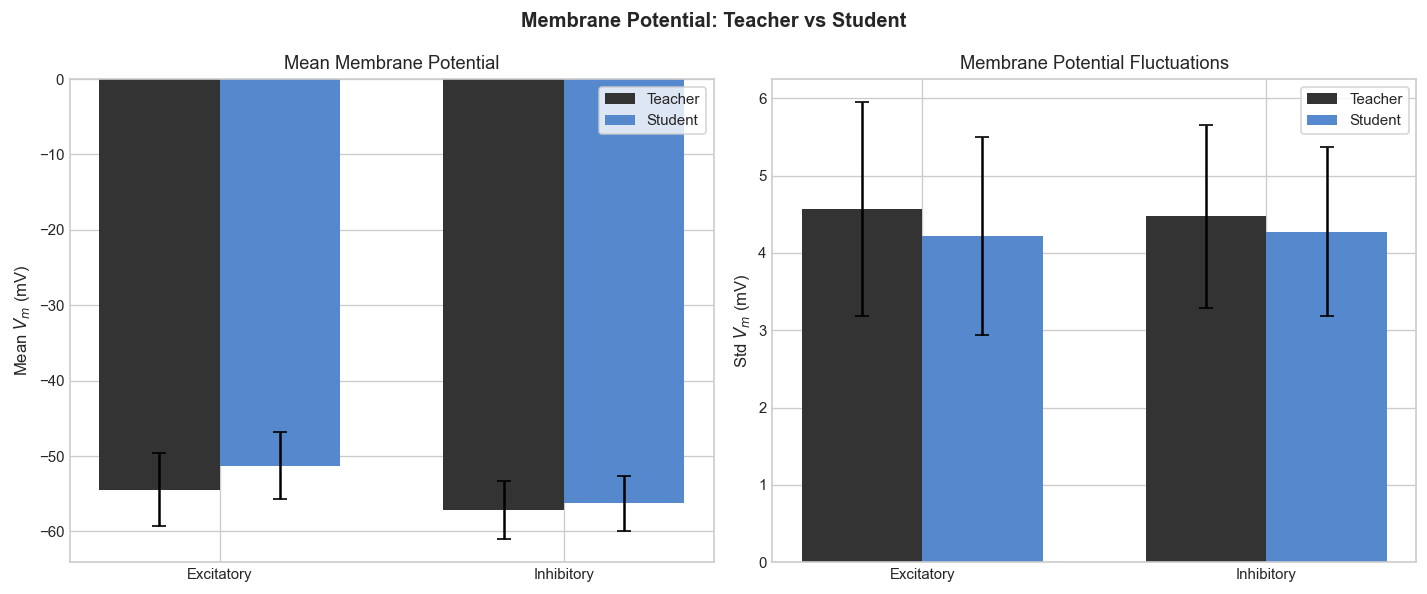

In [13]:
# Compute per-neuron mean and std of membrane potential, then summarise by cell type
# Add batch dim for the helper function: (1, time, neurons)
student_v_stats = compute_membrane_potential_by_cell_type(
    student_voltages[np.newaxis], cell_type_indices
)
teacher_v_stats = compute_membrane_potential_by_cell_type(
    teacher_voltages[np.newaxis], cell_type_indices
)

ct_names = {0: "Excitatory", 1: "Inhibitory"}

print(f"{'':20s} {'Mean Vm (mV)':>16s}  {'Std Vm (mV)':>16s}")
print(f"{'':20s} {'Teacher':>8s} {'Student':>8s}  {'Teacher':>8s} {'Student':>8s}")
print("-" * 72)
for ct_idx in [0, 1]:
    t = teacher_v_stats[ct_idx]
    s = student_v_stats[ct_idx]
    print(
        f"{ct_names[ct_idx]:<20s} "
        f"{t['mean_of_means']:8.2f} {s['mean_of_means']:8.2f}  "
        f"{t['mean_of_stds']:8.2f} {s['mean_of_stds']:8.2f}"
    )

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: mean Vm by cell type
ax = axes[0]
x = np.arange(2)
width = 0.35
teacher_means = [teacher_v_stats[ct]["mean_of_means"] for ct in [0, 1]]
student_means = [student_v_stats[ct]["mean_of_means"] for ct in [0, 1]]
teacher_means_err = [teacher_v_stats[ct]["std_of_means"] for ct in [0, 1]]
student_means_err = [student_v_stats[ct]["std_of_means"] for ct in [0, 1]]

ax.bar(
    x - width / 2,
    teacher_means,
    width,
    yerr=teacher_means_err,
    color=TEACHER_COLOR,
    label="Teacher",
    capsize=4,
)
ax.bar(
    x + width / 2,
    student_means,
    width,
    yerr=student_means_err,
    color=STUDENT_COLOR,
    label="Student",
    capsize=4,
)
ax.set_xticks(x)
ax.set_xticklabels(["Excitatory", "Inhibitory"])
ax.set_ylabel("Mean $V_m$ (mV)")
ax.set_title("Mean Membrane Potential")
ax.legend(frameon=True)

# Right: std Vm by cell type
ax = axes[1]
teacher_stds = [teacher_v_stats[ct]["mean_of_stds"] for ct in [0, 1]]
student_stds = [student_v_stats[ct]["mean_of_stds"] for ct in [0, 1]]
teacher_stds_err = [teacher_v_stats[ct]["std_of_stds"] for ct in [0, 1]]
student_stds_err = [student_v_stats[ct]["std_of_stds"] for ct in [0, 1]]

ax.bar(
    x - width / 2,
    teacher_stds,
    width,
    yerr=teacher_stds_err,
    color=TEACHER_COLOR,
    label="Teacher",
    capsize=4,
)
ax.bar(
    x + width / 2,
    student_stds,
    width,
    yerr=student_stds_err,
    color=STUDENT_COLOR,
    label="Student",
    capsize=4,
)
ax.set_xticks(x)
ax.set_xticklabels(["Excitatory", "Inhibitory"])
ax.set_ylabel("Std $V_m$ (mV)")
ax.set_title("Membrane Potential Fluctuations")
ax.legend(frameon=True)

plt.suptitle("Membrane Potential: Teacher vs Student", fontweight="bold")
plt.tight_layout()
plt.show()

## ISI / CV Statistics

Compare the coefficient of variation (CV = std(ISI) / mean(ISI)) between teacher and
student. A neuron driven by tonic input fires more regularly (low CV) than one driven
by fluctuations (high CV, closer to or above 1.0 for Poisson-like firing).

                              Mean CV         Median CV
                      Teacher  Student   Teacher  Student
------------------------------------------------------------------------
Excitatory              1.442    1.345     1.383    1.219
Inhibitory              2.001    1.991     1.888    1.880


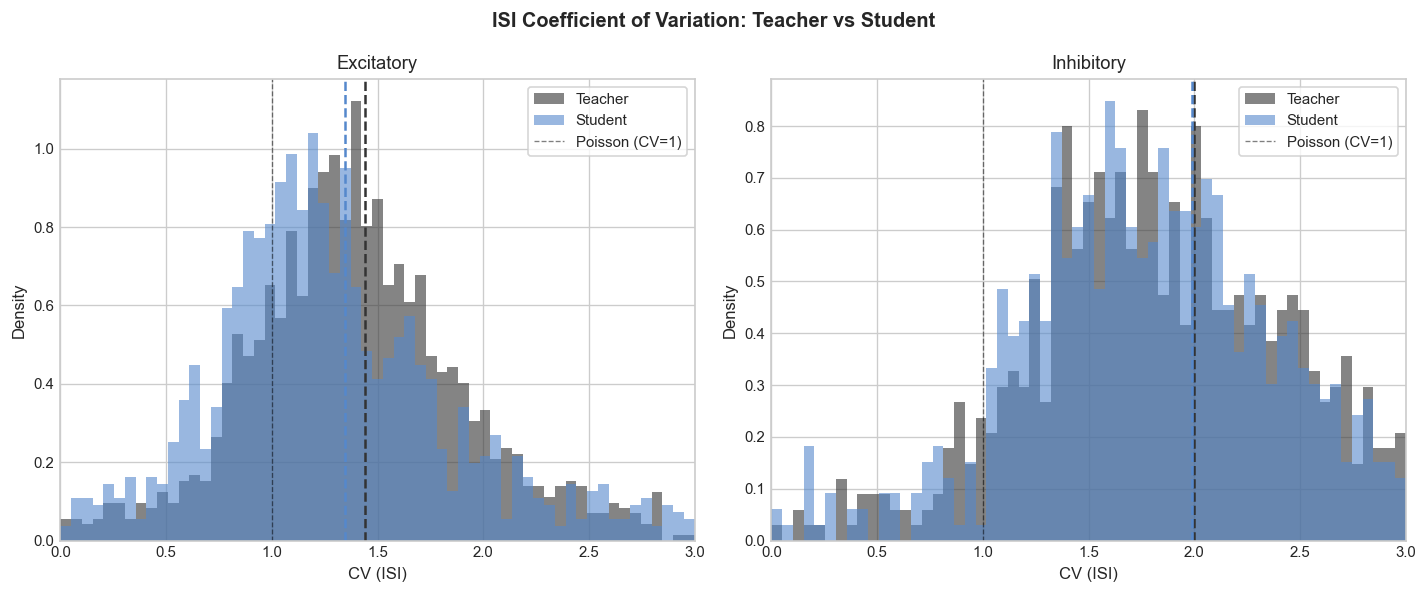

In [14]:
# Compute CV for teacher and student from the inference spike trains
# compute_spike_train_cv expects (batch, steps, neurons)
teacher_cv = compute_spike_train_cv(teacher_spikes[np.newaxis], dt=inf_dt * 1e-3)[0]
student_cv = compute_spike_train_cv(student_spikes[np.newaxis], dt=inf_dt * 1e-3)[0]

# Summary by cell type
ct_names = {0: "Excitatory", 1: "Inhibitory"}
print(f"{'':20s} {'Mean CV':>16s}  {'Median CV':>16s}")
print(f"{'':20s} {'Teacher':>8s} {'Student':>8s}  {'Teacher':>8s} {'Student':>8s}")
print("-" * 72)
for ct_idx in [0, 1]:
    mask = cell_type_indices == ct_idx
    t_cv = teacher_cv[mask]
    s_cv = student_cv[mask]
    t_valid = t_cv[~np.isnan(t_cv)]
    s_valid = s_cv[~np.isnan(s_cv)]
    print(
        f"{ct_names[ct_idx]:<20s} "
        f"{np.mean(t_valid):8.3f} {np.mean(s_valid):8.3f}  "
        f"{np.median(t_valid):8.3f} {np.median(s_valid):8.3f}"
    )

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cv_max = 3.0
bins = np.linspace(0, cv_max, 60)

for ax, ct_idx, ct_name in zip(axes, [0, 1], ["Excitatory", "Inhibitory"]):
    mask = cell_type_indices == ct_idx
    t_cv = teacher_cv[mask]
    s_cv = student_cv[mask]
    t_valid = t_cv[~np.isnan(t_cv)]
    s_valid = s_cv[~np.isnan(s_cv)]

    ax.hist(
        t_valid,
        bins=bins,
        alpha=0.6,
        color=TEACHER_COLOR,
        label="Teacher",
        density=True,
    )
    ax.hist(
        s_valid,
        bins=bins,
        alpha=0.6,
        color=STUDENT_COLOR,
        label="Student",
        density=True,
    )
    ax.axvline(
        1.0, color="k", linewidth=0.8, linestyle="--", alpha=0.5, label="Poisson (CV=1)"
    )
    ax.axvline(np.mean(t_valid), color=TEACHER_COLOR, linewidth=1.5, linestyle="--")
    ax.axvline(np.mean(s_valid), color=STUDENT_COLOR, linewidth=1.5, linestyle="--")
    ax.set_xlabel("CV (ISI)")
    ax.set_ylabel("Density")
    ax.set_title(f"{ct_name}")
    ax.legend(frameon=True, fontsize=9)
    ax.set_xlim(0, cv_max)

plt.suptitle("ISI Coefficient of Variation: Teacher vs Student", fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

In [17]:
summary = {
    "Activity R²": f"{r2_act:.4f}",
    f"Fluctuation R² (σ={TAU_MS:.0f} ms)": f"{r2_flu:.4f}",
    "Student FR (exc, Hz)": f"{student_fr[exc_mask].mean():.1f} ± {student_fr[exc_mask].std():.1f}",
    "Teacher FR (exc, Hz)": f"{teacher_fr[exc_mask].mean():.1f} ± {teacher_fr[exc_mask].std():.1f}",
    "Student FR (inh, Hz)": f"{student_fr[inh_mask].mean():.1f} ± {student_fr[inh_mask].std():.1f}",
    "Teacher FR (inh, Hz)": f"{teacher_fr[inh_mask].mean():.1f} ± {teacher_fr[inh_mask].std():.1f}",
    "Rec exc / FF ratio (student)": f"{student_rec_exc_drive / student_ff_drive:.3f}",
    "Rec exc / FF ratio (teacher)": f"{teacher_rec_exc_drive / teacher_ff_drive:.3f}",
    "Latent weight mean (exc)": f"{latent_w[:, exc_mask].mean():.6f}",
    "Latent weight mean (inh)": f"{latent_w[:, inh_mask].mean():.6f}",
}

for key in available_sf_keys:
    label = dict(SF_PATHWAYS).get(key, key)
    summary[f"SF {label}"] = f"{sf_final[key]:.4f}"

summary_df = pd.DataFrame([{"Metric": k, "Value": v} for k, v in summary.items()])
summary_df

,Metric,Value
0,Activity R²,0.8153
1,Fluctuation R² (σ=50 ms),0.7885
2,"Student FR (exc, Hz)",1.5 ± 5.7
3,"Teacher FR (exc, Hz)",2.5 ± 7.3
4,"Student FR (inh, Hz)",11.7 ± 23.8
5,"Teacher FR (inh, Hz)",13.1 ± 25.8
6,Rec exc / FF ratio (student),0.487
7,Rec exc / FF ratio (teacher),0.556
8,Latent weight mean (exc),0.015262
9,Latent weight mean (inh),0.003925
